In [2]:
import pandas as pd

dataset = pd.read_csv('fruits_dataset.csv')

In [3]:
dataset.head()

,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,Apple,Granny Smith,159.3,6.7,7.6,0.79
1,4,Mandarin,Satsuma,82.6,4.9,4.2,0.93
2,4,Mandarin,Satsuma,91.8,5.1,4.8,0.98
3,3,Orange,Valencia,179.4,7.5,8.7,0.83
4,1,Apple,Gala,169.5,6.6,7.1,0.90


In [4]:
dataset.shape

(100, 7)

In [5]:
dataset.groupby('fruit_name').size()

fruit_name
Apple       26
Lemon       29
Mandarin    25
Orange      20
dtype: int64

<Axes: xlabel='fruit_name', ylabel='count'>

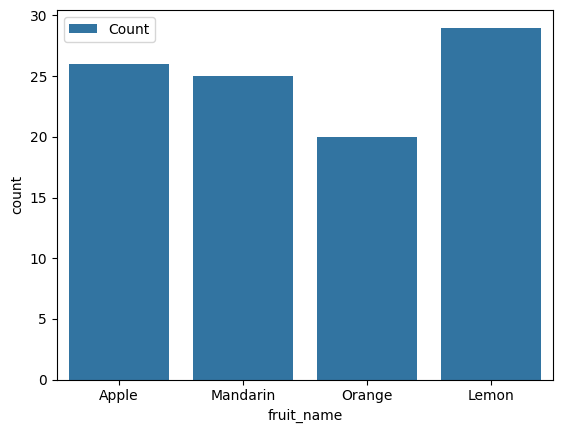

In [6]:
import seaborn as sns
sns.countplot(x=dataset['fruit_name'],label='Count')

<Axes: >

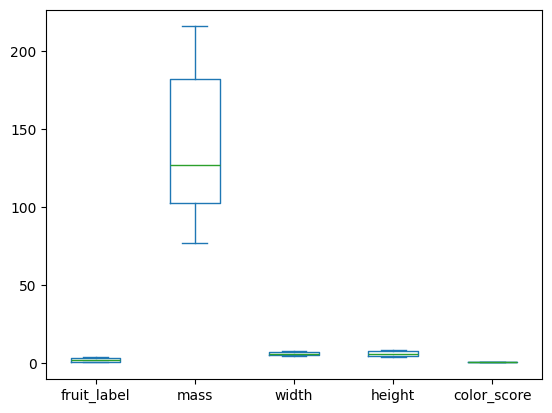

In [7]:
dataset.plot(kind='box')

mass              Axes(0.125,0.11;0.168478x0.77)
width          Axes(0.327174,0.11;0.168478x0.77)
height         Axes(0.529348,0.11;0.168478x0.77)
color_score    Axes(0.731522,0.11;0.168478x0.77)
dtype: object

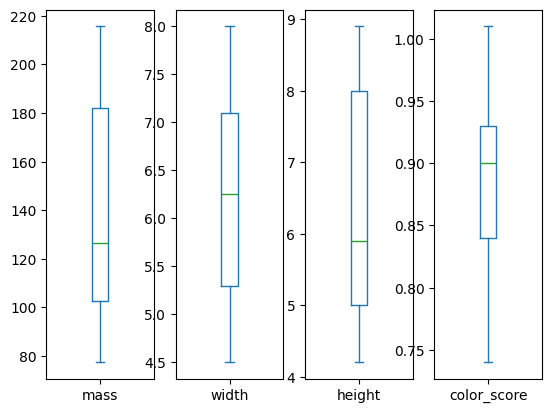

In [8]:
dataset.drop('fruit_label',axis=1).plot(kind='box',subplots=True)

mass              Axes(0.125,0.53;0.352273x0.35)
width          Axes(0.547727,0.53;0.352273x0.35)
height            Axes(0.125,0.11;0.352273x0.35)
color_score    Axes(0.547727,0.11;0.352273x0.35)
dtype: object

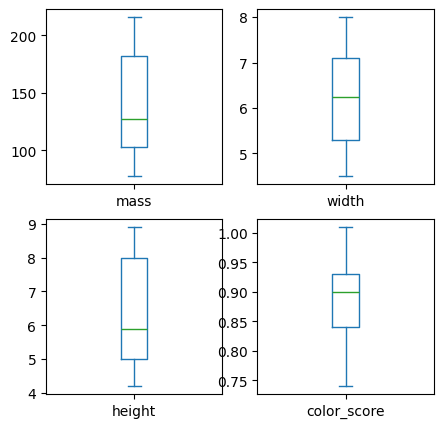

In [9]:
dataset.drop('fruit_label',axis=1).plot(kind='box',subplots=True,layout=(2,2),sharex=False,figsize=(5,5))

Text(0.5, 0.98, 'Histogram for each numarical input value')

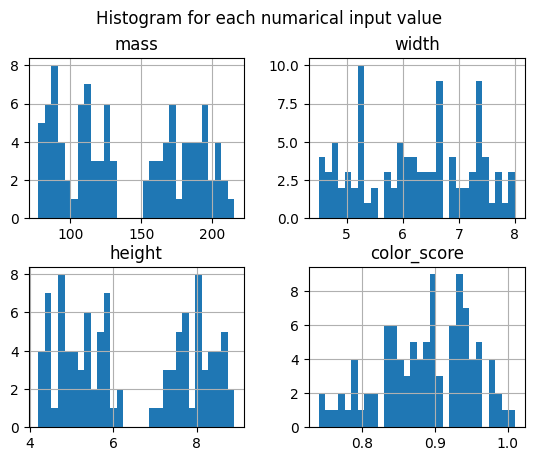

In [10]:
import pylab as pl

dataset.drop('fruit_label',axis=1).hist(bins=30)
pl.suptitle('Histogram for each numarical input value')


In [11]:
from sklearn.model_selection import train_test_split

feature_names = ['mass','width','height','color_score']
X = dataset[feature_names] # this is input
Y = dataset['fruit_label'] # this is output 

X_train , X_test, Y_train, Y_test = train_test_split(X, Y,random_state=0)

In [12]:
Y_train

48    1
6     2
99    2
82    1
76    3
     ..
96    1
67    2
64    4
47    4
44    4
Name: fruit_label, Length: 75, dtype: int64

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


In [14]:
from sklearn.linear_model import LinearRegression

linearreg = LinearRegression()
linearreg.fit(X_train, Y_train)

linearreg.score(X_train,Y_train)

0.4939664487724167

In [15]:
linearreg.score(X_test,Y_test)

0.0152817889369955

In [16]:
# Decision tree

from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier()
clf.fit(X_train, Y_train)

clf.score(X_train, Y_train)

1.0

In [17]:
clf.score(X_test, Y_test)

0.8

In [20]:
# KNN classification

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, Y_train)

knn.score(X_train, Y_train)

0.9333333333333333

In [21]:
knn.score(X_test, Y_test)

0.96

In [26]:
import numpy as np
from collections import Counter

def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((np.array(point1) - np.array(point2))**2))

def knn_predict(training_data, training_labels, test_point, k):
    distances = []
    for i in range(len(training_data)):
        dist = euclidean_distance(test_point, training_data[i])
        distances.append((dist, training_labels[i]))
    distances.sort(key=lambda x: x[0])
    print(distances[:k])
    k_nearest_labels = [label for _, label in distances[:k]]
    return Counter(k_nearest_labels).most_common(1)[0][0]

training_data = [[1, 2], [2, 3], [3, 4], [6, 7], [7, 8]]
training_labels = ['A', 'A', 'A', 'B', 'B']
test_point = [4, 5]
k = 3

prediction = knn_predict(training_data, training_labels, test_point, k)
print(prediction)

[(np.float64(1.4142135623730951), 'A'), (np.float64(2.8284271247461903), 'A'), (np.float64(2.8284271247461903), 'B')]
A


In [28]:
# Naive Bayes

from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train,Y_train)

gnb.score(X_train,Y_train)

0.9466666666666667

In [29]:
gnb.score(X_test,Y_test)

0.88

In [31]:
# Support Vector Machines Classification

from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train,Y_train)

svm.score(X_train,Y_train)


0.9466666666666667

In [32]:
svm.score(X_test,Y_test)

0.92